In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn 

In [2]:
from pathlib import Path

candidates = [Path("adult.csv"), *Path.cwd().glob("**/adult.csv")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find 'adult.csv' in current folder or subfolders.")

df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path.resolve()}")
df.head()

Loaded data from: C:\Users\ACER\Desktop\TUKE\2\INSA\adult.csv


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [4]:
df.describe()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


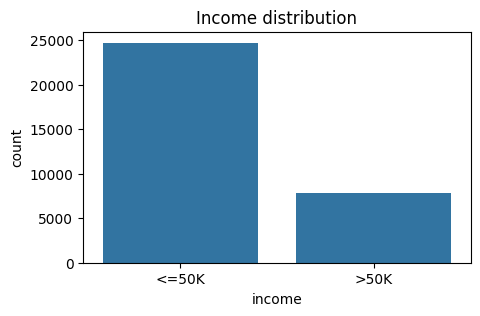

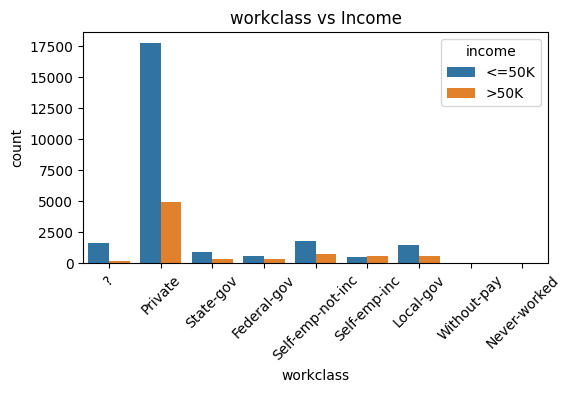

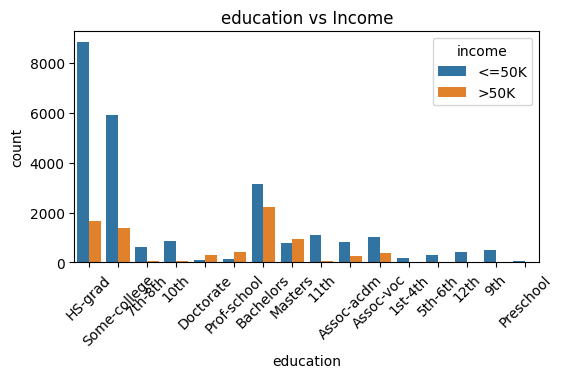

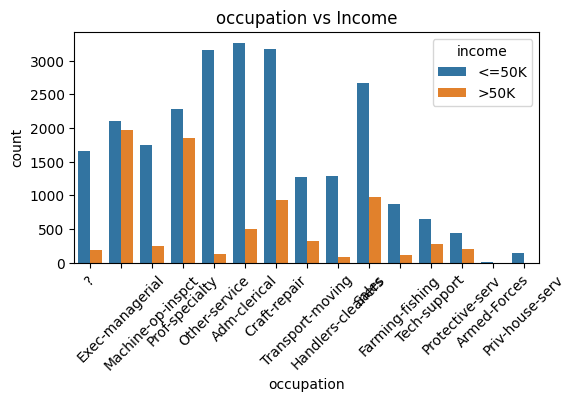

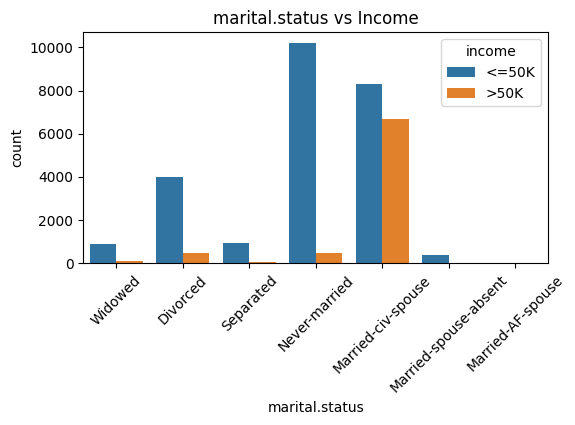

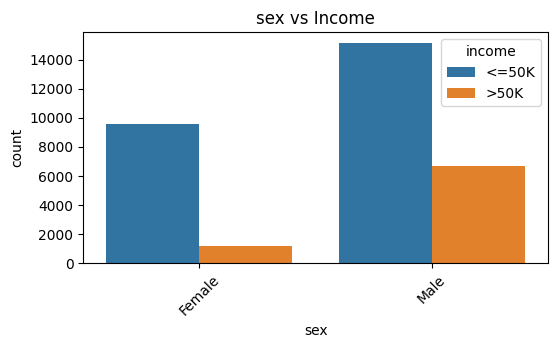

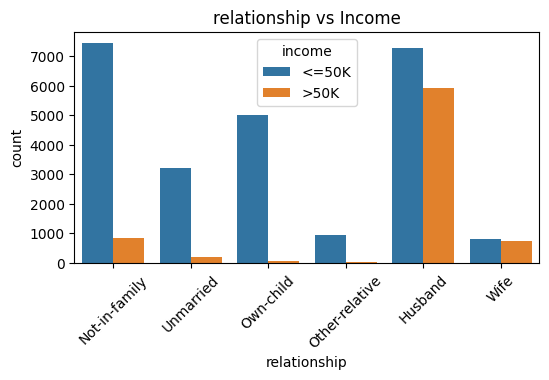

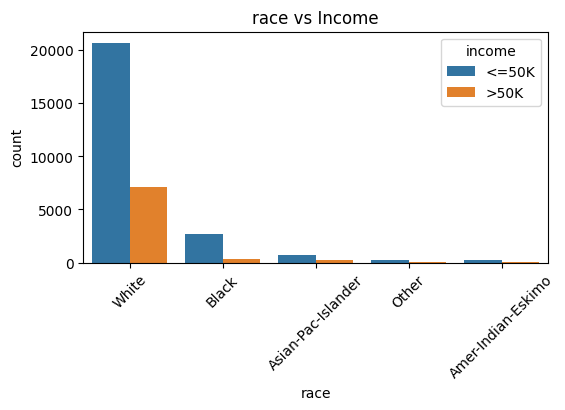

In [5]:
plt.figure(figsize=(5,3))
sns.countplot(x='income', data=df)
plt.title('Income distribution')
plt.show()

for c in ['workclass','education','occupation','marital.status', 'sex', 'relationship', 'race']:
    if c in df.columns:
        plt.figure(figsize=(6,3))
        sns.countplot(x=c, hue='income', data=df)
        plt.xticks(rotation=45)
        plt.title(f'{c} vs Income')
        plt.show()


In [6]:
pd.crosstab(df['relationship'], df['sex'])

sex,Female,Male
relationship,,
Husband,1,13192
Not-in-family,3875,4430
Other-relative,430,551
Own-child,2245,2823
Unmarried,2654,792
Wife,1566,2


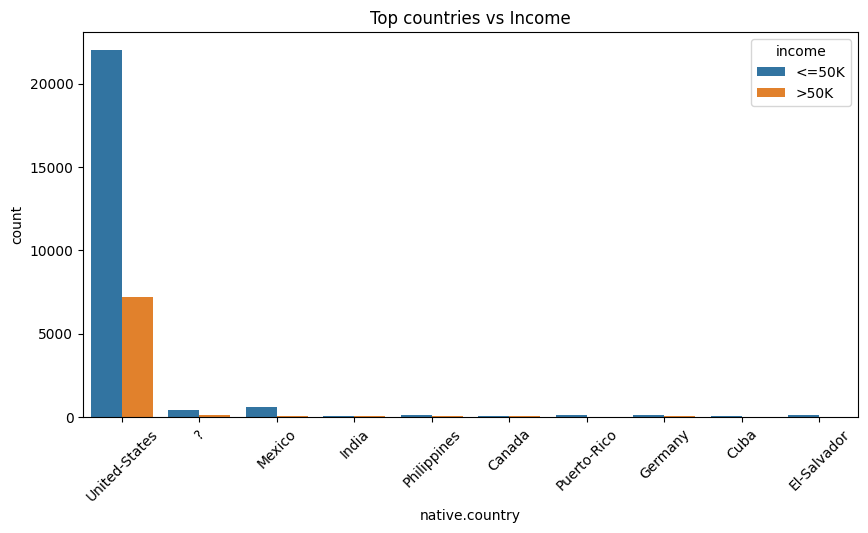

In [7]:
top_countries = df['native.country'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['native.country'].isin(top_countries)],
              x='native.country', hue='income')

plt.xticks(rotation=45)
plt.title("Top countries vs Income")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

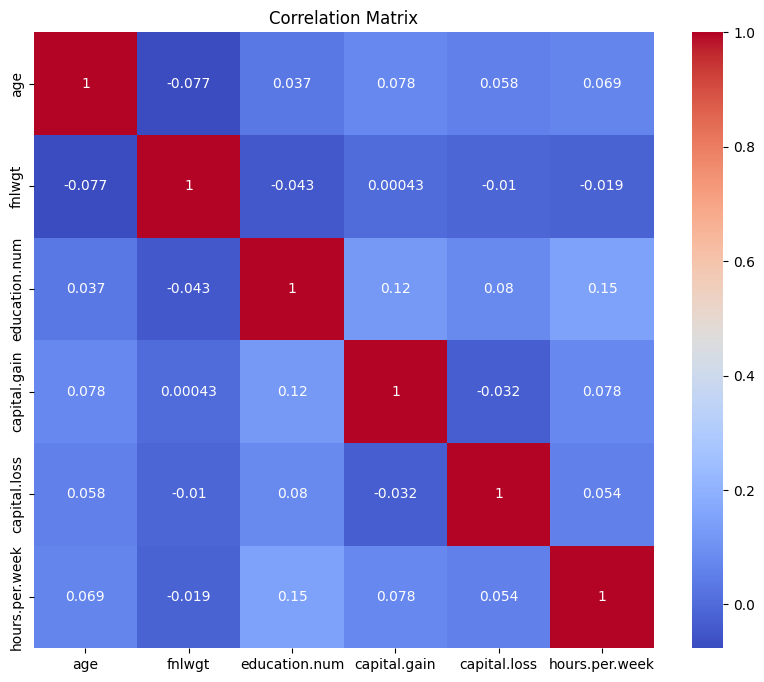

In [8]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

In [9]:
df['capital.gain.log'] = np.log1p(df["capital.gain"])
df['capital.loss.log'] = np.log1p(df["capital.loss"])

In [10]:
df['work_hours_age_ratio'] = df['hours.per.week'] / (df['age'])

In [11]:
df["native.country_US"] = df["native.country"] == "United-States"
df.drop('native.country', axis=1, inplace=True)

In [12]:
df["is_male"] = df["sex"] == "Male"
df.drop('sex', axis=1, inplace=True)

In [13]:
df["income"] = df["income"] == ">50K"

In [14]:
(df == '?').sum()

age                        0
workclass               1836
fnlwgt                     0
education                  0
education.num              0
marital.status             0
occupation              1843
relationship               0
race                       0
capital.gain               0
capital.loss               0
hours.per.week             0
income                     0
capital.gain.log           0
capital.loss.log           0
work_hours_age_ratio       0
native.country_US          0
is_male                    0
dtype: int64

In [15]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=np.number).columns

qmark_before = (
    df[cat_cols]
    .apply(lambda s: s.astype(str).str.fullmatch(r"\s*\?\s*", na=False).sum())
    .sum()
)

df[cat_cols] = df[cat_cols].replace(r"^\s*\?\s*$", np.nan, regex=True)

for col in cat_cols:
    if df[col].isna().any():
        mode_vals = df[col].mode()
        if not mode_vals.empty:
            df[col] = df[col].fillna(mode_vals.iloc[0])

for col in num_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

cat_missing_after = df[cat_cols].isna().sum().sum()
num_missing_after = df[num_cols].isna().sum().sum()

print("'?'-like markers before cleaning:", int(qmark_before))
print("Missing categorical values after cleaning:", int(cat_missing_after))
print("Missing numeric values after cleaning:", int(num_missing_after))

'?'-like markers before cleaning: 3679
Missing categorical values after cleaning: 0
Missing numeric values after cleaning: 0


In [16]:
df.drop(['fnlwgt', 'relationship', 'education.num', 'capital.gain','capital.loss'], axis=1, inplace=True)
df

,age,workclass,education,marital.status,occupation,race,hours.per.week,income,capital.gain.log,capital.loss.log,work_hours_age_ratio,native.country_US,is_male
0,90,Private,HS-grad,Widowed,Prof-specialty,White,40,False,0.0,8.379539,0.444444,True,False
1,82,Private,HS-grad,Widowed,Exec-managerial,White,18,False,0.0,8.379539,0.219512,True,False
2,66,Private,Some-college,Widowed,Prof-specialty,Black,40,False,0.0,8.379539,0.606061,True,False
3,54,Private,7th-8th,Divorced,Machine-op-inspct,White,40,False,0.0,8.268988,0.740741,True,False
4,41,Private,Some-college,Separated,Prof-specialty,White,40,False,0.0,8.268988,0.975610,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,Some-college,Never-married,Protective-serv,White,40,False,0.0,0.000000,1.818182,True,True
32557,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,White,38,False,0.0,0.000000,1.407407,True,False
32558,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,White,40,True,0.0,0.000000,1.000000,True,True
32559,58,Private,HS-grad,Widowed,Adm-clerical,White,40,False,0.0,0.000000,0.689655,True,False


## Feature Selection

Some features were removed because they provide similar information or are not very useful for this model.

- `education.num` contains the same information as `education`, so only one of them is needed.
- `relationship` is closely related to `marital.status` and `sex`, so it was removed to avoid redundancy.
- `fnlwgt` is only a survey weight and does not represent a personal characteristic.
- `capital.gain` and `capital.loss` were replaced with their log-transformed versions to reduce skewness.

In [17]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].nunique())

workclass 8
education 16
marital.status 7
occupation 14
race 5


In [18]:
df = pd.get_dummies(
    df,
    columns=['workclass', 'education', 'occupation', 'marital.status', 'race'],
    drop_first=True
)
df

,age,hours.per.week,income,capital.gain.log,capital.loss.log,work_hours_age_ratio,native.country_US,is_male,workclass_Local-gov,workclass_Never-worked,...,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,90,40,False,0.0,8.379539,0.444444,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,82,18,False,0.0,8.379539,0.219512,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,66,40,False,0.0,8.379539,0.606061,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,54,40,False,0.0,8.268988,0.740741,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,41,40,False,0.0,8.268988,0.975610,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,40,False,0.0,0.000000,1.818182,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True
32557,27,38,False,0.0,0.000000,1.407407,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
32558,40,40,True,0.0,0.000000,1.000000,True,True,False,False,...,False,True,False,False,False,False,False,False,False,True
32559,58,40,False,0.0,0.000000,0.689655,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [19]:
df.shape

(32561, 53)

In [20]:
df.head()

,age,hours.per.week,income,capital.gain.log,capital.loss.log,work_hours_age_ratio,native.country_US,is_male,workclass_Local-gov,workclass_Never-worked,...,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,90,40,False,0.0,8.379539,0.444444,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,82,18,False,0.0,8.379539,0.219512,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,66,40,False,0.0,8.379539,0.606061,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,54,40,False,0.0,8.268988,0.740741,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,41,40,False,0.0,8.268988,0.975610,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True


Target and features

## What We Predict
Target variable: `income`.
Positive class (`True`): income > 50K.
Task: binary classification to predict whether a person earns more than 50K.

In [21]:
X = df.drop('income', axis = 1)
y = df['income']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score
from sklearn.base import clone

X_fit_lr, X_val_lr, y_fit_lr, y_val_lr = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="liblinear"))
])

lr_grid = GridSearchCV(
    lr_pipe,
    {
        "clf__C": [0.1, 0.5, 1.0, 2.0],
        "clf__penalty": ["l1", "l2"],
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)
lr_grid.fit(X_fit_lr, y_fit_lr)

val_probs_lr = lr_grid.best_estimator_.predict_proba(X_val_lr)[:, 1]
thresholds_lr = np.arange(0.20, 0.81, 0.02)
f1_vals_lr = [f1_score(y_val_lr, val_probs_lr >= t) for t in thresholds_lr]
best_threshold_lr = float(thresholds_lr[int(np.argmax(f1_vals_lr))])

lr = clone(lr_grid.best_estimator_)
lr.fit(X_train, y_train)
y_prob = lr.predict_proba(X_test)[:, 1]
y_pred_lr = y_prob >= best_threshold_lr

scores_lr = lr_grid.cv_results_["mean_test_score"]
print("Best Logistic Regression params:", lr_grid.best_params_)
print("Best Logistic Regression CV F1:", round(lr_grid.best_score_, 4))
print("Best Logistic Regression threshold (val F1):", round(best_threshold_lr, 2))

Best Logistic Regression params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Best Logistic Regression CV F1: 0.6542
Best Logistic Regression threshold (val F1): 0.32


In [30]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.base import clone

X_fit_knn, X_val_knn, y_fit_knn, y_val_knn = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    knn_pipe,
    {
        "clf__n_neighbors": [5, 9, 15, 21, 31],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)
knn_grid.fit(X_fit_knn, y_fit_knn)

val_probs_knn = knn_grid.best_estimator_.predict_proba(X_val_knn)[:, 1]
thresholds_knn = np.arange(0.20, 0.81, 0.02)
f1_vals_knn = [f1_score(y_val_knn, val_probs_knn >= t) for t in thresholds_knn]
best_threshold_knn = float(thresholds_knn[int(np.argmax(f1_vals_knn))])

knn_best = clone(knn_grid.best_estimator_)
knn_best.fit(X_train, y_train)

scores_knn = knn_grid.cv_results_["mean_test_score"]
y_prob_knn = knn_best.predict_proba(X_test)[:, 1]
y_pred_knn = y_prob_knn >= best_threshold_knn

print("Best kNN params:", knn_grid.best_params_)
print("Best kNN CV F1:", round(knn_grid.best_score_, 4))
print("Best kNN threshold (val F1):", round(best_threshold_knn, 2))

Best kNN params: {'clf__n_neighbors': 15, 'clf__p': 1, 'clf__weights': 'uniform'}
Best kNN CV F1: 0.6275
Best kNN threshold (val F1): 0.34


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score

X_fit_tree, X_val_tree, y_fit_tree, y_val_tree = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [6, 8, 10, None],
        "min_samples_split": [10, 30, 50],
        "min_samples_leaf": [5, 10, 20],
        "class_weight": [None, "balanced"],
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)
tree_grid.fit(X_fit_tree, y_fit_tree)

tree_best = tree_grid.best_estimator_
val_probs_tree = tree_best.predict_proba(X_val_tree)[:, 1]
thresholds_tree = np.arange(0.20, 0.81, 0.02)
f1_vals_tree = [f1_score(y_val_tree, val_probs_tree >= t) for t in thresholds_tree]
best_threshold_tree = float(thresholds_tree[int(np.argmax(f1_vals_tree))])

tree_best.fit(X_train, y_train)

scores_tree = tree_grid.cv_results_["mean_test_score"]
y_prob_tree = tree_best.predict_proba(X_test)[:, 1]
y_pred_tree = y_prob_tree >= best_threshold_tree

print("Best Tree params:", tree_grid.best_params_)
print("Best Tree CV F1:", round(tree_grid.best_score_, 4))
print("Best Tree threshold (val F1):", round(best_threshold_tree, 2))

Best Tree params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best Tree CV accuracy: 0.8567


In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import numpy as np

# Hold-out validation to tune decision threshold after model search
X_fit_nn, X_val_nn, y_fit_nn, y_val_nn = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

cv_nn = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

nn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=12,
        max_iter=900,
        random_state=42
    ))
])

nn_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions={
        "clf__hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128)],
        "clf__activation": ["relu", "tanh"],
        "clf__alpha": [1e-4, 1e-3, 5e-3],
        "clf__learning_rate_init": [3e-4, 5e-4, 1e-3],
        "clf__batch_size": [64, 128],
        "clf__solver": ["adam"],
    },
    n_iter=6,
    scoring="f1",
    cv=cv_nn,
    n_jobs=1,
    random_state=42,
    verbose=0
)

nn_search.fit(X_fit_nn, y_fit_nn)

# Find best probability threshold on validation split (optimize F1)
val_probs_nn = nn_search.best_estimator_.predict_proba(X_val_nn)[:, 1]
thresholds = np.arange(0.20, 0.81, 0.02)
f1_vals = [f1_score(y_val_nn, val_probs_nn >= t) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_vals))])

nn = clone(nn_search.best_estimator_)
nn.fit(X_train, y_train)

scores_nn = nn_search.cv_results_["mean_test_score"]
y_prob_nn = nn.predict_proba(X_test)[:, 1]
y_pred_nn = y_prob_nn >= best_threshold

print("Best NN params:", nn_search.best_params_)
print("Best NN CV F1:", round(nn_search.best_score_, 4))
print("Best NN threshold (val F1):", round(best_threshold, 2))

Best NN params: {'clf__solver': 'adam', 'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128, 64), 'clf__batch_size': 64, 'clf__alpha': 0.005, 'clf__activation': 'relu'}
Best NN CV F1: 0.6708
Best NN threshold (val F1): 0.3


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame({
    "Logistic Regression": evaluate(y_test, y_pred_lr),
    "kNN (tuned)": evaluate(y_test, y_pred_knn),
    "Decision Tree (tuned)": evaluate(y_test, y_pred_tree),
    "Neural Network": evaluate(y_test, y_pred_nn),
}).T

results = results.round(4)
results


,Accuracy,Precision,Recall,F1
Logistic Regression,0.8268,0.6145,0.7532,0.6768
kNN (tuned),0.8248,0.6137,0.7347,0.6688
Decision Tree (tuned),0.8532,0.7589,0.5721,0.6524
Neural Network,0.8188,0.5928,0.7902,0.6774


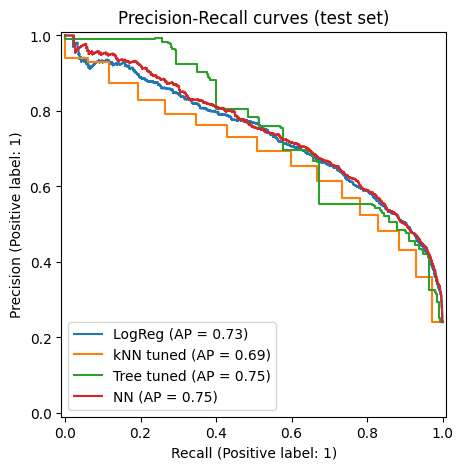

In [32]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="LogReg", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_prob_knn, name="kNN tuned", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_prob_tree, name="Tree tuned", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_prob_nn, name="NN", ax=plt.gca())
plt.title("Precision-Recall curves (test set)")
plt.show()

## Conclusion
Based on the evaluation on the test dataset, the Neural Network achieved the highest F1 score (0.6774) and recall (0.7902), which means it performs better at detecting high-income cases. Logistic Regression produced very similar results with an F1 score of 0.6768 and can still be considered a strong baseline because of its simplicity. The Decision Tree achieved the highest accuracy (0.8532) and precision (0.7589), suggesting that it makes fewer incorrect positive predictions. Overall, if the goal is to detect as many high-income cases as possible, the Neural Network performs best, while the Decision Tree may be preferred when accuracy and precision are more important.